# Iris Classification with Model Comparison

In [38]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, mean_squared_error, r2_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the Dataset
iris = load_iris()
X = iris.data # Features
y = iris.target # Labels
print(X.shape) # (150 samples, 4 features)
print(y.shape) # (150,)

print(X[:5])

(150, 4)
(150,)
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]


In [3]:
# Split Data (Train/Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [4]:
# Feature Scaling
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

In [5]:
# Train the Classifier
model = LogisticRegression()
model.fit(X_train_s, y_train)

LogisticRegression()

In [6]:
# Make Predictions
y_pred = model.predict(X_test_s)

In [7]:
# Evaluate the Model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:", cm, sep="\n")

print("Classification Report:", classification_report(y_test, y_pred), sep="\n")

Accuracy: 1.0
Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [8]:
# Trying Another Classifier
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_s, y_train)
y_pred_knn = knn.predict(X_test_s)
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

KNN Accuracy: 1.0


In [9]:
accuracy = accuracy_score(y_test, y_pred_knn)
print("Accuracy:", accuracy)

cm = confusion_matrix(y_test, y_pred_knn)
print("Confusion Matrix:", cm, sep="\n")

print("Classification Report:", classification_report(y_test, y_pred_knn), sep="\n")

Accuracy: 1.0
Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



**1. Which model performed better? Why?**  
Both preformed equally have same accuracy and confusion matrix.

**2. How does scaling affect KNN performance?**  
Scaling improves KNN because it relies on distance measures; without scaling, features with larger ranges dominate, leading to biased and less accurate predictions.  

**3. Which class is most misclassified?**  
As accurac is 1 no class is misclassified. 

# Effect of Feature Scaling

In [10]:
# Training without scaling
model2 = LogisticRegression()
model2.fit(X_train, y_train)

# Predict Model
y_pred_2 = model2.predict(X_test)

# Evaluate the Model
accuracy = accuracy_score(y_test, y_pred_2)
print("Accuracy:", accuracy)

cm = confusion_matrix(y_test, y_pred_2)
print("Confusion Matrix:", cm, sep="\n")

print("Classification Report:", classification_report(y_test, y_pred_2), sep="\n")

Accuracy: 1.0
Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [11]:
# Training with scaling
model3 = LogisticRegression()
model3.fit(X_train_s, y_train)

# Predict Model
y_pred_3 = model3.predict(X_test_s)

# Evaluate the Model
accuracy = accuracy_score(y_test, y_pred_3)
print("Accuracy:", accuracy)

cm = confusion_matrix(y_test, y_pred_3)
print("Confusion Matrix:", cm, sep="\n")

print("Classification Report:", classification_report(y_test, y_pred_3), sep="\n")

Accuracy: 1.0
Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



**1. Why does scaling improve performance?**  
Scaling improves performance because it prevents large‑range features from dominating distance or gradient calculations, ensuring all features contribute equally.  

**2. Which algorithms require scaling most?**  
Distance and gradient‑based algorithms need scaling most, such as KNN, SVM, Logistic/Linear Regression, and PCA.  

# Regression Model Comparison

In [12]:
from sklearn.datasets import fetch_california_housing

# Load the Dataset
data = fetch_california_housing()
X = data.data # Features
y = data.target # Target
print(X.shape) # (20640 samples, 8 features)
print(y.shape) # (20640,)

# Split Data (Train/Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Feature Scaling
scaler2 = StandardScaler()
X_train = scaler2.fit_transform(X_train)
X_test = scaler2.transform(X_test)

# Train the Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Make Predictions
y_pred = model.predict(X_test)

# Evaluate the Model
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)
rmse = np.sqrt(mse)
print("RMSE:", rmse)
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)


(20640, 8)
(20640,)
MSE: 0.5558915986952442
RMSE: 0.7455813830127763
R2 Score: 0.575787706032451


In [14]:
# Trying Another Regression Model
from sklearn.tree import DecisionTreeRegressor
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)
print("Decision Tree Evaluation:", r2_score(y_test, y_pred_tree))
# Evaluate the Model
mse = mean_squared_error(y_test, y_pred_tree)
print("MSE:", mse)
rmse = np.sqrt(mse)
print("RMSE:", rmse)
r2 = r2_score(y_test, y_pred_tree)
print("R2 Score:", r2)

Decision Tree Evaluation: 0.6230424613065773
MSE: 0.49396854311945243
RMSE: 0.7028289572288925
R2 Score: 0.6230424613065773


**1. Which model performed better?**  
Decision tree outperformed Linear Regression on non-linear data because they capture complex patterns more effectively.  

**2. Why does Decision Tree behave differently from Linear Regression?**  
Decision Trees split data into regions using thresholds, handling non-linear relationships and categorical variables, while Linear Regression assumes a straight-line relationship between features and target.  

**3. Which metric is more interpretable (RMSE vs MSE)?**  
RMSE is more interpretable because it is in the same units as the target variable, making the error magnitude easier to understand compared to MSE, which is in squared units.  

# Understanding Evaluation Metrics (Classification)

Manual Accuracy:  0.75
Accuracy:  0.75
Manual Precision: 0.75
Precision: 0.75
Manual Recall: 0.75
Recall: 0.75
Manuall f1 score:  0.75
F1 Score: 0.75
Confusion Matrix Manual:
[ 3 1 ]
[ 1 3 ]

Confusion Matrix:  [[3 1]
 [1 3]]


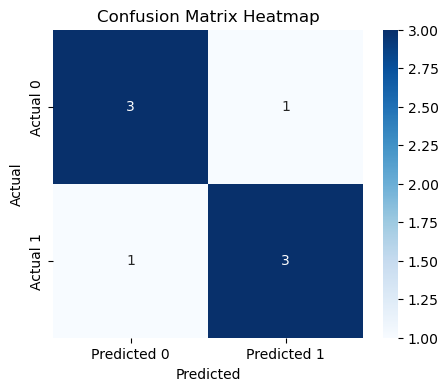

In [29]:
y_true = [0, 1, 0, 1, 0, 1, 1, 0]
y_pred = [0, 1, 0, 0, 0, 1, 1, 1]

print("Manual Accuracy: ", 6 / 8) 
print("Accuracy: ", accuracy_score(y_true, y_pred))
print("Manual Precision:", 3 / 4)
print("Precision:", precision_score(y_true, y_pred))
print("Manual Recall:", 3 / 4)
print("Recall:", recall_score(y_true, y_pred))
print("Manuall f1 score: ", (2 * 3/4 * 3/4) / (3/4 + 3/4))
print("F1 Score:", f1_score(y_true, y_pred))

print("Confusion Matrix Manual:")
print("[ 3 1 ]")
print("[ 1 3 ]")

cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix: ", cm)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
xticklabels=['Predicted 0','Predicted 1'], yticklabels=['Actual 0','Actual 1'])
plt.title('Confusion Matrix Heatmap')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

**1.When is accuracy misleading?**  
Accuracy can be misleading in imbalanced datasets, where predicting only the majority class gives high accuracy but poor performance on minority classes.

**2.When is precision more important than recall?**  
Precision matters more when false positives are costly, such as fraud detection or spam filtering, where wrongly flagging legitimate cases is harmful.

**3.Real-world example for high recall importance:**  
Medical screening (e.g., cancer detection) requires high recall to ensure most true cases are identified, even if it means some false alarms.

# ROC Curve & Model Performance

ROC-AUC Score: 0.75


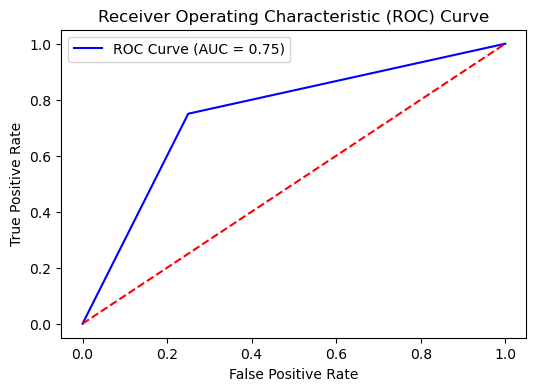

In [39]:
roc_auc = roc_auc_score(y_true, y_pred)
print("ROC-AUC Score:", roc_auc)
fpr, tpr, thresholds = roc_curve(y_true, y_pred)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], color='red', linestyle='--')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

# Train-Test Split Importance

In [40]:
iris = load_iris()
X, y = iris.data, iris.target

# -----------------------------
# 1. Train on full dataset
# -----------------------------
model_full = LogisticRegression(max_iter=200)
model_full.fit(X, y)
y_pred_full = model_full.predict(X)
accuracy_full = accuracy_score(y, y_pred_full)
print("Accuracy (trained on full dataset):", accuracy_full)

# -----------------------------
# 2. Train-test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model_split = LogisticRegression(max_iter=200)
model_split.fit(X_train, y_train)

# Accuracy on training data
y_train_pred = model_split.predict(X_train)
accuracy_train = accuracy_score(y_train, y_train_pred)

# Accuracy on test data
y_test_pred = model_split.predict(X_test)
accuracy_test = accuracy_score(y_test, y_test_pred)

print("Accuracy (train set):", accuracy_train)
print("Accuracy (test set):", accuracy_test)

Accuracy (trained on full dataset): 0.9733333333333334
Accuracy (train set): 0.9619047619047619
Accuracy (test set): 1.0


**Overfitting:**
When the model memorizes training data too closely, including noise, leading to poor performance on unseen test data. We notice very high training accuracy but much lower test accuracy.

**Why not train on test data?**
The test set is meant to represent unseen data. Training on it contaminates evaluation, giving misleadingly high accuracy that doesn’t reflect real-world performance.

**Data leakage:**
Occurs when information from outside the training set (like test data or future variables) leaks into training. Example: If you accidentally normalize the entire dataset before splitting, the test set statistics influence training.